In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

DATA_PATH_TAS = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [ ]:
DIR_LIST = os.listdir(DATA_PATH_TAS)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(DATA_PATH_TAS, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

In [9]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Evaluation-Tier2/Amon/tas'

DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((21, 1488, 72, 144), dtype=np.float32)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J','K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 1/21: tas_mon_2A.190001-202312.nc
  Found test data for A at index 0
  Tas shape: (1488, 72, 144)
  Processing 2/21: tas_mon_2B.190001-202312.nc
  Found test data for B at index 1
  Tas shape: (1488, 72, 144)
  Processing 3/21: tas_mon_2C.190001-202312.nc
  Found test data for C at index 2
  Tas shape: (1488, 72, 144)
  Processing 4/21: tas_mon_2D.190001-202312.nc
  Found test data for D at index 3
  Tas shape: (1488, 72, 144)
  Processing 5/21: tas_mon_2E.190001-202312.nc
  Found test data for E at index 4
  Tas shape: (1488, 72, 144)
  Processing 6/21: tas_mon_2F.190001-202312.nc
  Found test data for F at index 5
  Tas shape: (1488, 72, 144)
  Processing 7/21: tas_mon_2G.190001-202312.nc
  Found test data for G at index 6
  Tas shape: (1488, 72, 144)
  Processing 8/21: tas_mon_2H.190001-202312.nc
  Found test data for H at index 7
  Tas shape: (1488, 72, 144)
  Processing 9/21: tas_mon_2I.190001-202312.nc
  Found test data for I at index 8
  Tas shape: (1488, 72, 144)
 

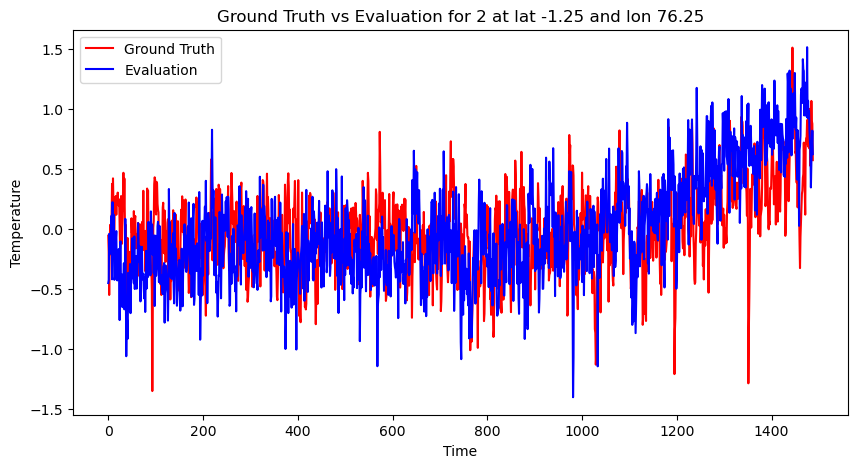

In [10]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 2
idx_lat = 35
idx_lon = 30

x_tmp = data_test[idx_run+1,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [12]:
import torch

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [13]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [14]:
# compute training set and test set
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)

  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


# Get yearly data

In [15]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data , months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

# Reshape the data to have the shape (runs, years, latitude * longitude)
x_test = data_test.reshape(data_test.shape[0], data_test.shape[1], longitude.shape[0]*latitude.shape[0])

x_test_yearly = yearly_average(data_test, months_per_year=12)
x_test_yearly = x_test_yearly.reshape(x_test_yearly.shape[0], x_test_yearly.shape[1], longitude.shape[0]*latitude.shape[0])

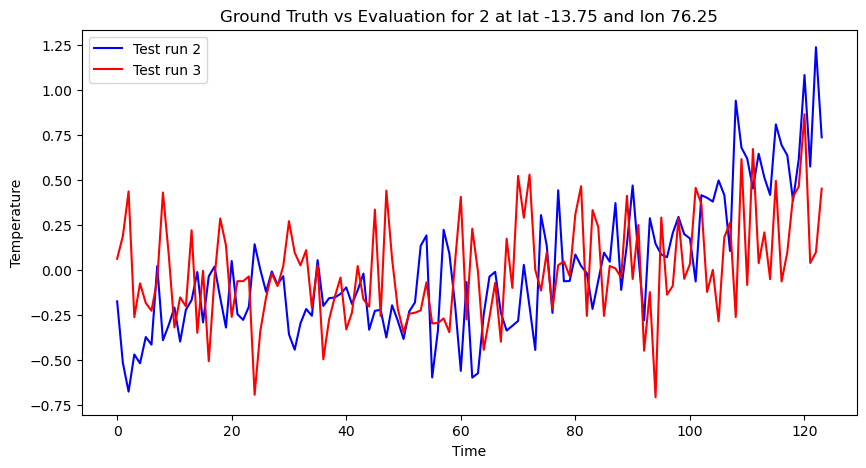

In [20]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(x_test_yearly.reshape(x_test_yearly.shape[0],x_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Test run 2', color='blue')
plt.plot(x_test_yearly.reshape(x_test_yearly.shape[0],x_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])[3,:,idx_lat,idx_lon], label='Test run 3', color='red')
# plt.plot(y_test_yearly.reshape(10,y_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='forced response', color='red')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [21]:
# get training data in one single matrix
x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])


# Ridge regression: $\min_{W} \ \lVert Y - XW \rVert_{F}^2 + \lambda \lVert W \rVert_{F}^2$

In [23]:
from algorithms import ridge_regression

# penalty parameters
lambda_tmp = 2500.0

# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

Loss function:  465614.0625


# Low-rank regression: $\min_{W \colon \mathrm{rank}(W) \leq r} \ \lVert Y - XW \rVert_{F}^2 + \lambda \lVert W \rVert_{F}^2$

In [24]:
# SVD decomposition (only once)
U,S,V = torch.linalg.svd(x_train_yearly@w_ridge,full_matrices=False)

In [25]:
# get low-rank truncation of the ridge regression solution
rank = 5
w_ridge_low_rank = w_ridge @ V[:rank,:].T@V[:rank,:]

In [26]:
x_test_torch = torch.from_numpy(x_test).to(torch.float32)

# preditcion on test data
y_pred = x_test_torch @ w_ridge
y_pred_lr = x_test_torch @ w_ridge_low_rank

In [48]:
x_test[2,:100,100]

array([5.4838714e+19, 5.5645166e+19, 5.5645166e+19, 5.6451619e+19,
       5.6451619e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.5645166e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.4838714e+19, 5.5645166e+19, 5.5645166e+19, 5.6451619e+19,
       5.6451619e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.5645166e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.4838714e+19, 5.5645166e+19, 5.5645166e+19, 5.6451619e+19,
       5.6451619e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.5645166e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.4838714e+19, 5.5645166e+19, 5.5645166e+19, 5.6451619e+19,
       5.6451619e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.5645166e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.4838714e+19, 5.5645166e+19, 5.5645166e+19, 5.6451619e+19,
       5.6451619e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e+19,
       5.5645166e+19, 5.6451619e+19, 5.6451619e+19, 5.5645166e

Text(0.5, 1.0, 'Ridge Regression vs Low Rank Ridge Regression at lat 11.25 and lon 76.25')

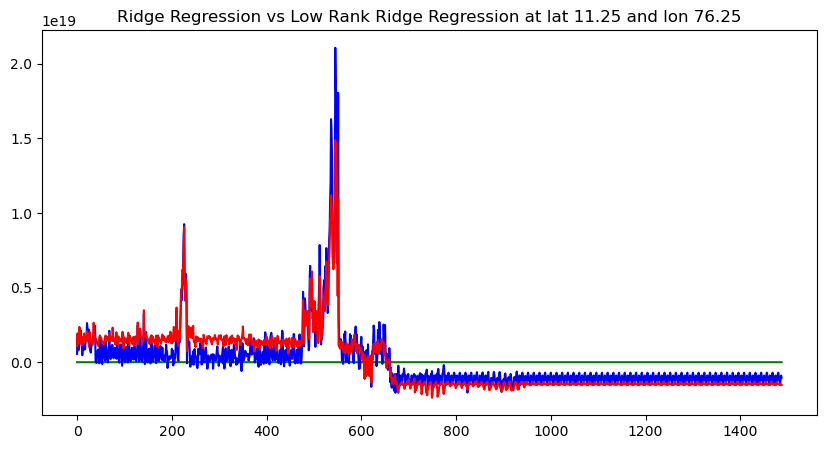

In [49]:
# display some time series
idx_lat = 40
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(x_test.reshape(x_test.shape[0],x_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Evaluation member', color='green')
plt.plot(y_pred.reshape(y_pred.shape[0],y_pred.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ridge Regression', color='blue')
plt.plot(y_pred_lr.reshape(y_pred_lr.shape[0],y_pred_lr.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Low Rank Ridge Regression', color='red')
plt.title(f'Ridge Regression vs Low Rank Ridge Regression at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')

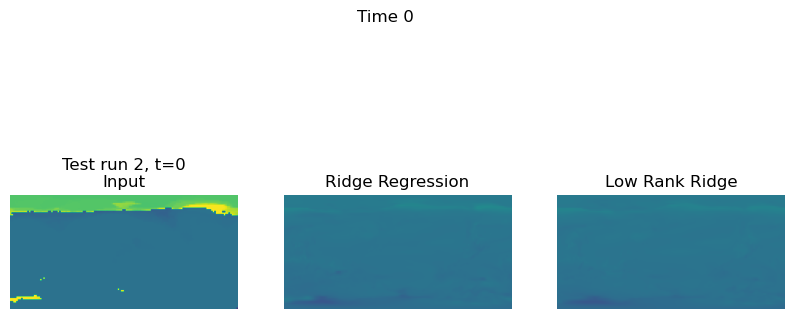

In [44]:
# display animation of the prediction
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

vmin = np.nanmin(x_test[idx_run])  # or set to a fixed value for all frames
vmax = np.nanmax(x_test[idx_run])

def animate(i):
    plt.clf()
    plt.subplot(1, 3, 1)
    plt.imshow(x_test.reshape(x_test.shape[0],x_test.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,i,:,:], label='Test run 2',vmin=vmin, vmax=vmax)
    plt.title(f"Test run {idx_run}, t={i}\nInput")
    plt.axis('off')

    # Ridge Regression
    plt.subplot(1, 3, 2)  
    plt.imshow(y_pred.reshape(x_test.shape[0],x_test.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,i,:,:].detach().numpy(), label='Ridge Regression', vmin=vmin, vmax=vmax)
    plt.title("Ridge Regression")
    plt.axis('off')

    # Low Rank Ridge Regression
    plt.subplot(1, 3, 3)
    
    plt.imshow(y_pred_lr.reshape(x_test.shape[0],x_test.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,i,:,:].detach().numpy(), label='Low Rank Ridge Regression', vmin=vmin, vmax=vmax)
    plt.title("Low Rank Ridge")
    plt.axis('off')

    plt.suptitle(f"Time {i}")

fig = plt.figure(figsize=(10, 5))
anim= FuncAnimation(fig, animate, frames=x_test.shape[1], interval=200)
anim.save('forcesmip6_Tier2_ridge_regression.mp4', writer='ffmpeg', fps=10)
# plt.show()

In [31]:
x_test_yearly.shape

(21, 124, 10368)